<a href="https://colab.research.google.com/github/pacayton/Forecasting_Codes/blob/main/Ch_3_Forecasters_Toolbox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
install.packages(c("fpp2", "tidyverse", "forecast"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘expsmooth’, ‘fma’, ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’




In [ ]:
## Preamble Code

###

library(fpp2)
library(tidyverse)
library(forecast)

── Attaching packages ──────────────────────────────────────────── fpp2 2.5.1 ──

✔ ggplot2   4.0.1     ✔ fma       2.5  
✔ forecast  9.0.1     ✔ expsmooth 2.3  



── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [ ]:
## Sample Data to be used from Github:

philmonth <- read_csv("https://raw.githubusercontent.com/pacayton/Forecasting_Codes/refs/heads/main/Datasets/PhilMonthlyData.csv")

philquarter <- read_csv("https://raw.githubusercontent.com/pacayton/Forecasting_Codes/refs/heads/main/Datasets/PhilQuarterData.csv")


Rows: 264 Columns: 37
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (36): cpi, cpifbt, deporate_savings, dubaicrude, expenditures, exports,...
date  (1): _date_

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 112 Columns: 19
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (18): agri, volpal, dubai, cpi, expt, gdp, gov, impt, ind, libor3, nfia...
date  (1): _date_

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
## Example:

volpal <- ts(philquarter$volpal, start = 1981, frequency = 4) |> na.omit()

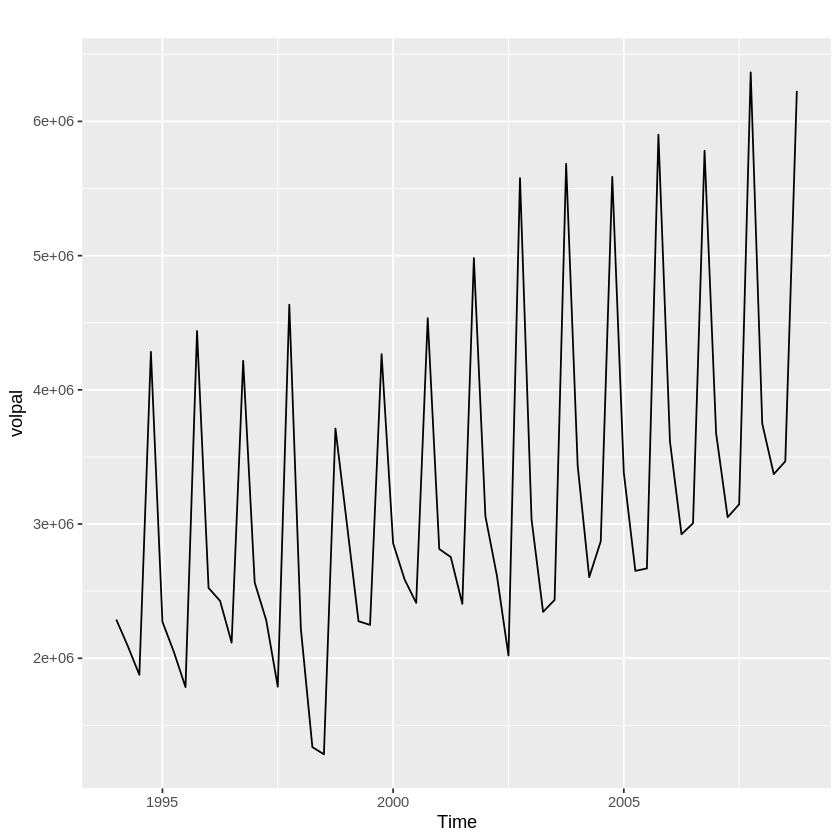

In [ ]:
autoplot(volpal)

In [ ]:
# train-test split

volpal_train <- window(volpal, end = c(2006,4))
volpal_test <- window(volpal, start = c(2007,1))

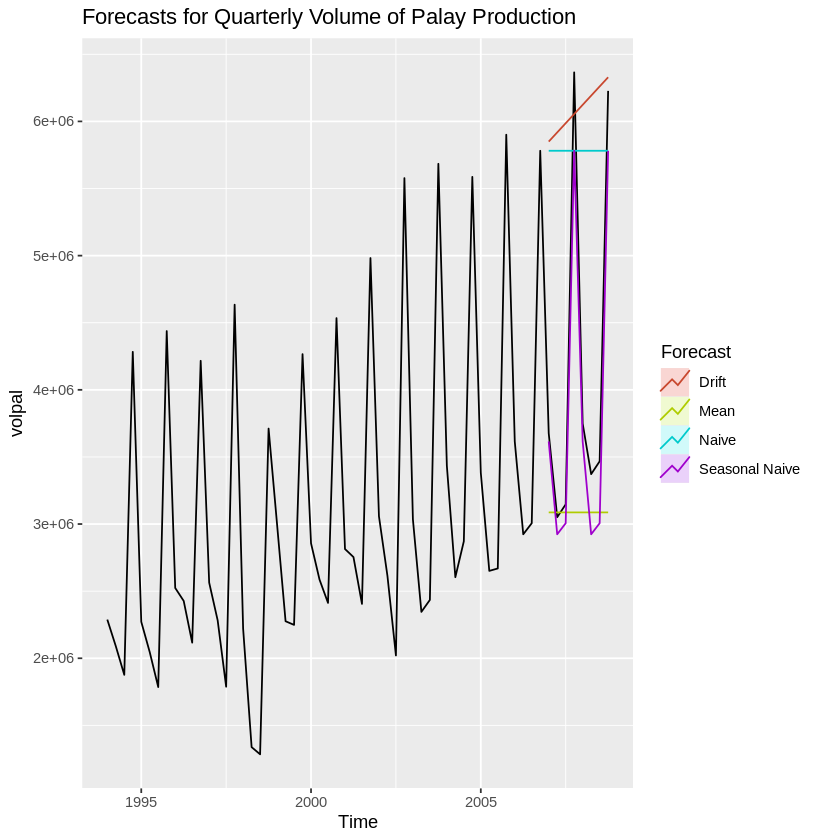

In [ ]:
autoplot(volpal) +
  autolayer(meanf(volpal_train, h = 8), series = "Mean", PI = F) +
  autolayer(naive(volpal_train, h = 8), series = "Naive", PI = F) +
  autolayer(snaive(volpal_train, h = 8), series = "Seasonal Naive", PI = F) +
  autolayer(rwf(volpal_train, h = 8, drift = T), series = "Drift", PI = F) +
  ggtitle("Forecasts for Quarterly Volume of Palay Production") +
  guides(colour = guide_legend(title = "Forecast"))

In [ ]:
## Calendar Adjustments

mrt3 <- ts(philmonth$mrt3, start = 1989, frequency = 12) |> na.omit()

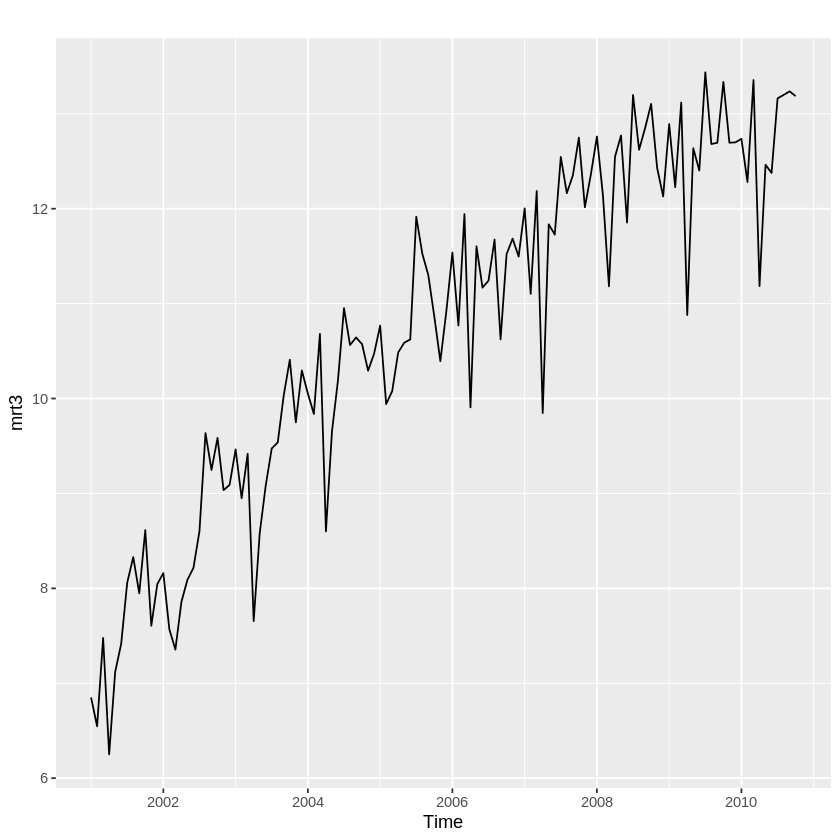

In [ ]:
autoplot(mrt3)

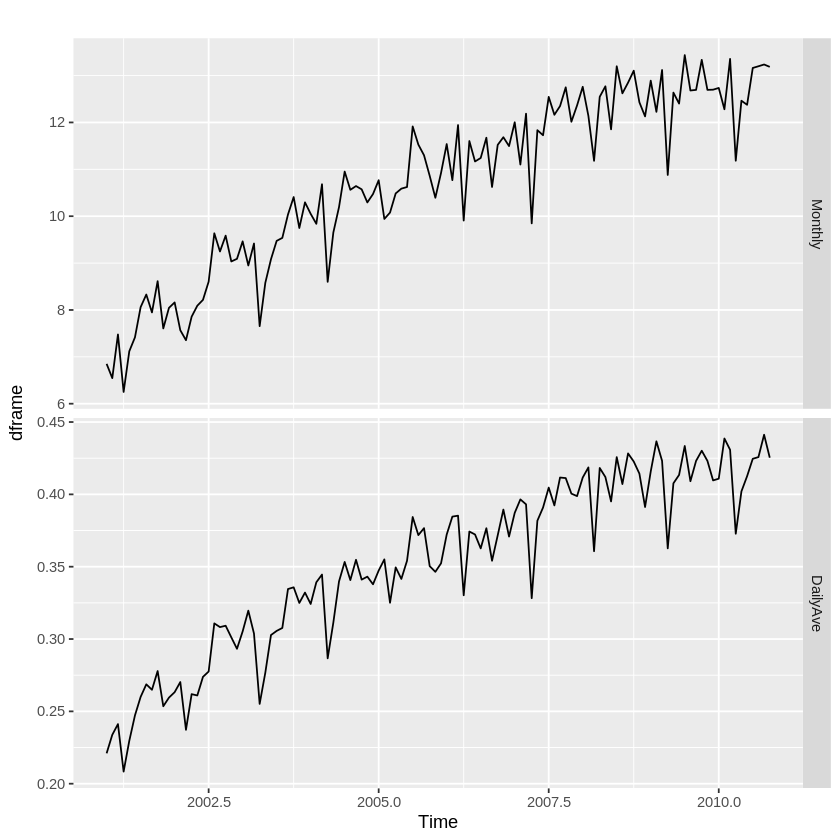

In [ ]:
dframe <- cbind(Monthly = mrt3,
                DailyAve = mrt3/monthdays(mrt3))

autoplot(dframe, facet = TRUE)

In [ ]:
BoxCox.lambda(mrt3)

[1] 1.357402

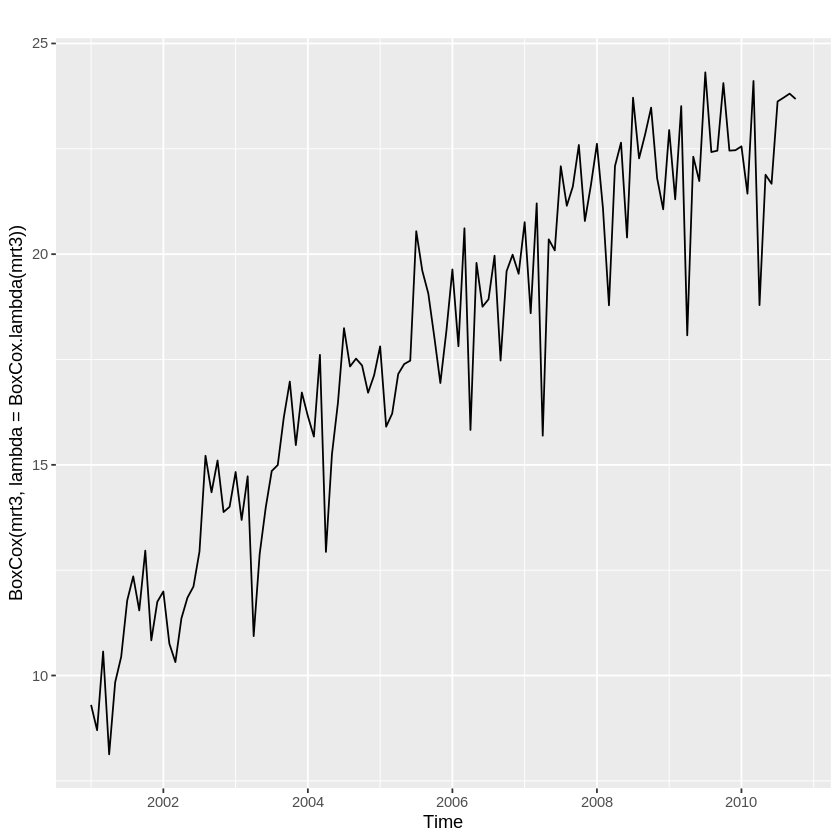

In [ ]:
BoxCox(mrt3, lambda = BoxCox.lambda(mrt3)) |> autoplot()

[1] 1.416418

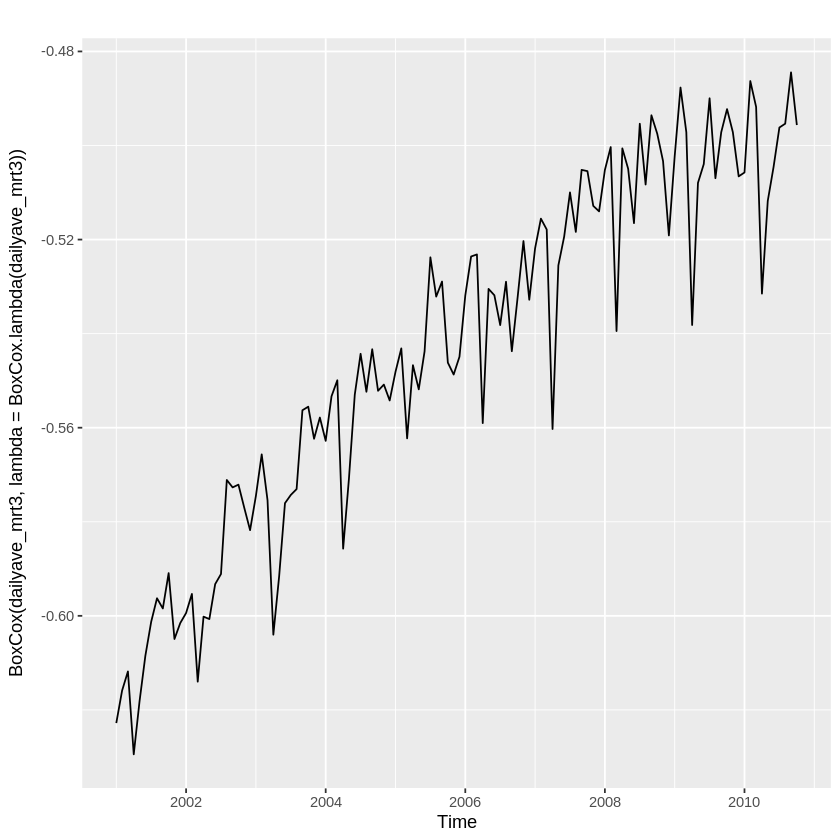

In [ ]:
dailyave_mrt3 <- mrt3/monthdays(mrt3)
BoxCox.lambda(dailyave_mrt3)
BoxCox(dailyave_mrt3,
       lambda = BoxCox.lambda(dailyave_mrt3)) |> autoplot()

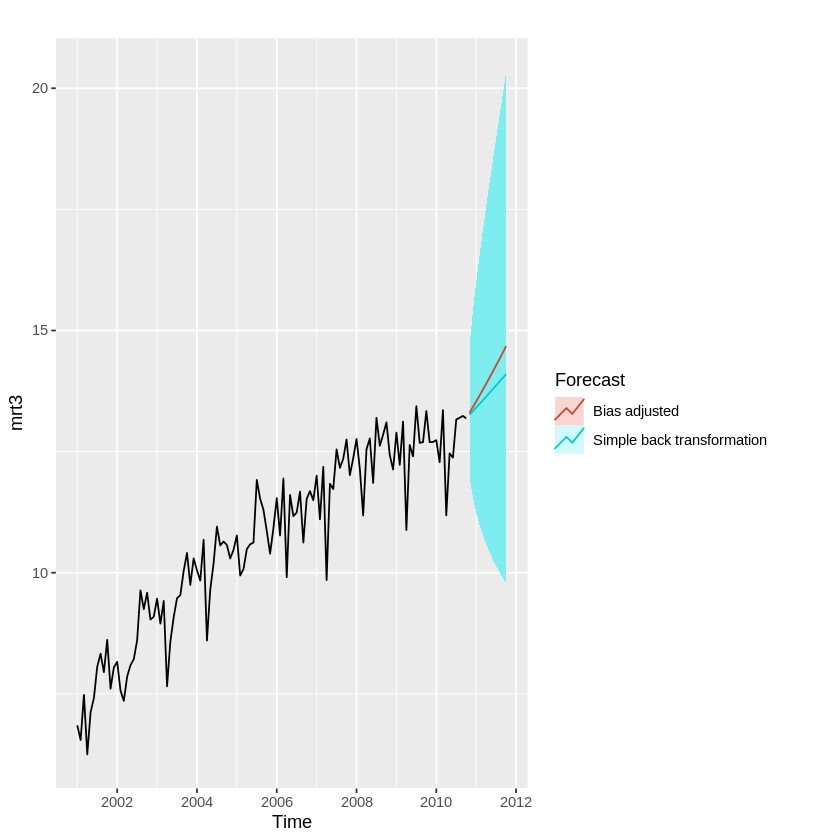

In [ ]:
fc <- rwf(mrt3, drift=TRUE, lambda=0, h=12, level=80)
fc2 <- rwf(mrt3, drift=TRUE, lambda=0, h=12, level=80,
  biasadj=TRUE)
autoplot(mrt3) +
  autolayer(fc, series="Simple back transformation") +
  autolayer(fc2, series="Bias adjusted", PI=FALSE) +
  guides(colour=guide_legend(title="Forecast"))

In [ ]:
## Residuals
psei <- read_csv("https://github.com/pacayton/Forecasting_Codes/raw/refs/heads/main/Datasets/PSEI.PS_AdjClose.csv")
psei <- ts(psei$PSEI, start = 1, end = 260)

Rows: 2920 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (1): PSEI
date (1): Date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


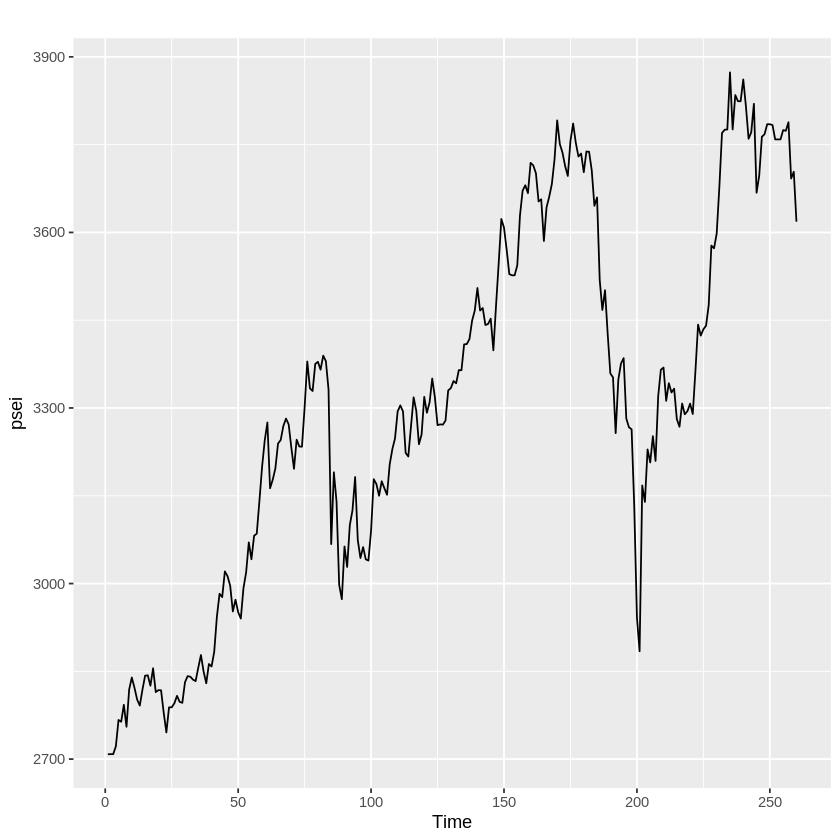

In [ ]:
autoplot(psei)

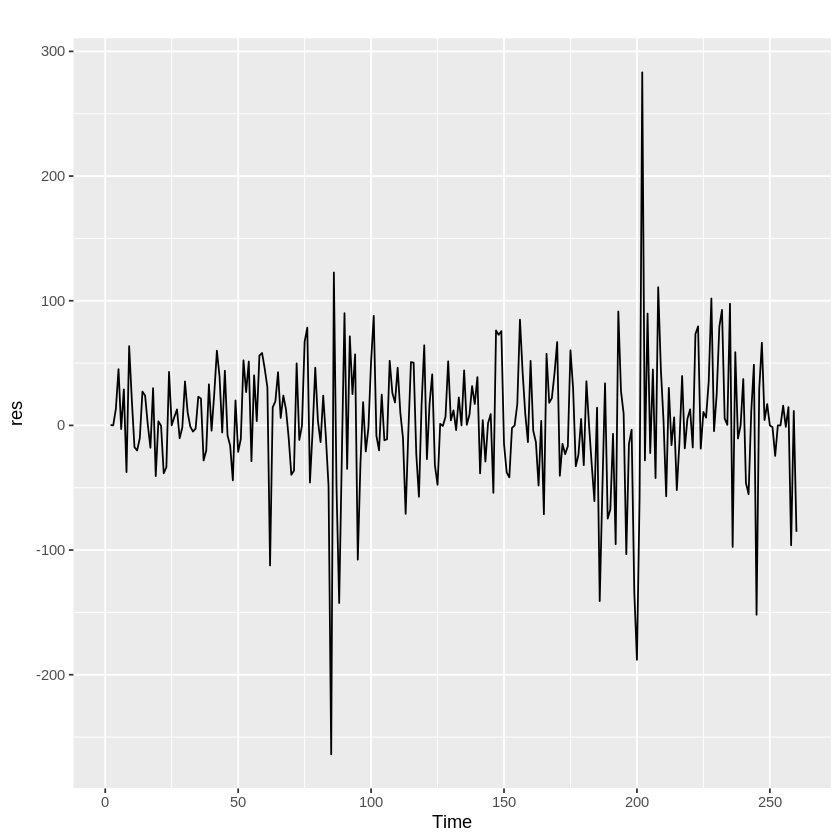

In [ ]:
res <- psei |> naive() |> residuals()
res |> autoplot()

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_rug()`).”


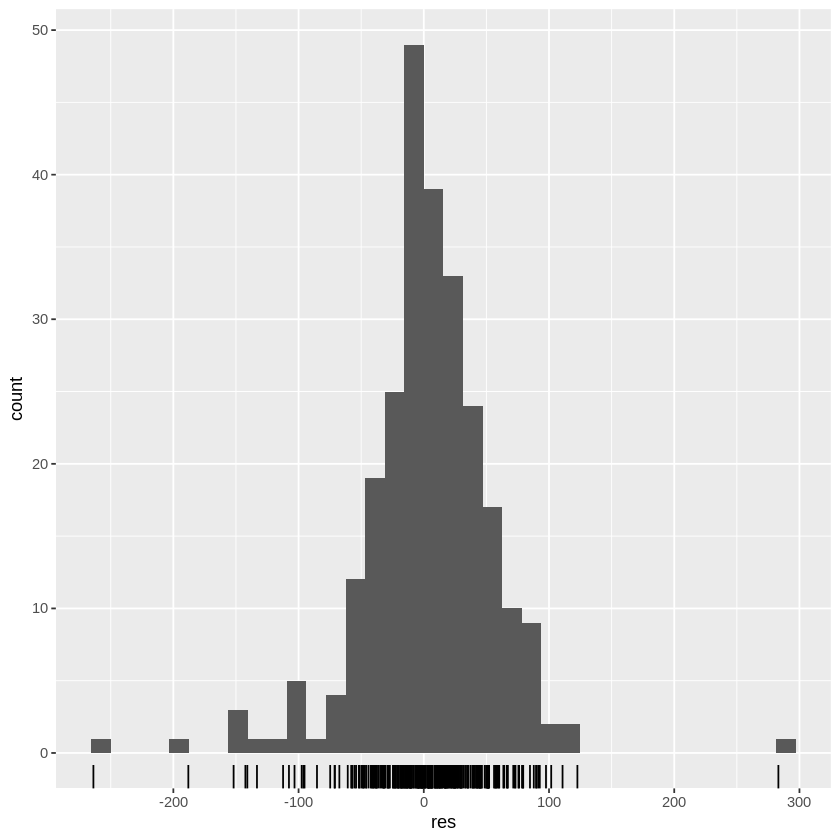

In [ ]:
gghistogram(res)

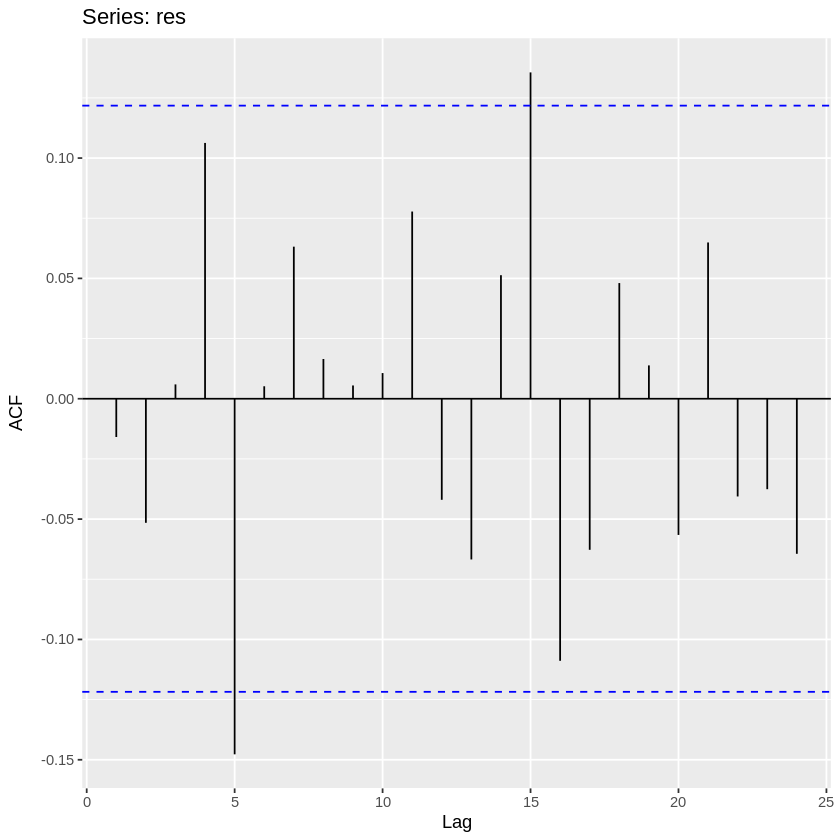

In [ ]:
ggAcf(res)

In [ ]:
shapiro.test(res)


	Shapiro-Wilk normality test

data:  res
W = 0.92399, p-value = 3.06e-10


In [ ]:
Box.test(res, lag = 20)


	Box-Pierce test

data:  res
X-squared = 24.685, df = 20, p-value = 0.2138


In [ ]:
Box.test(res, lag = 20, type = "Lj")


	Box-Ljung test

data:  res
X-squared = 25.955, df = 20, p-value = 0.1673



	Ljung-Box test

data:  Residuals from Naive method
Q* = 10.769, df = 10, p-value = 0.3758

Model df: 0.   Total lags used: 10



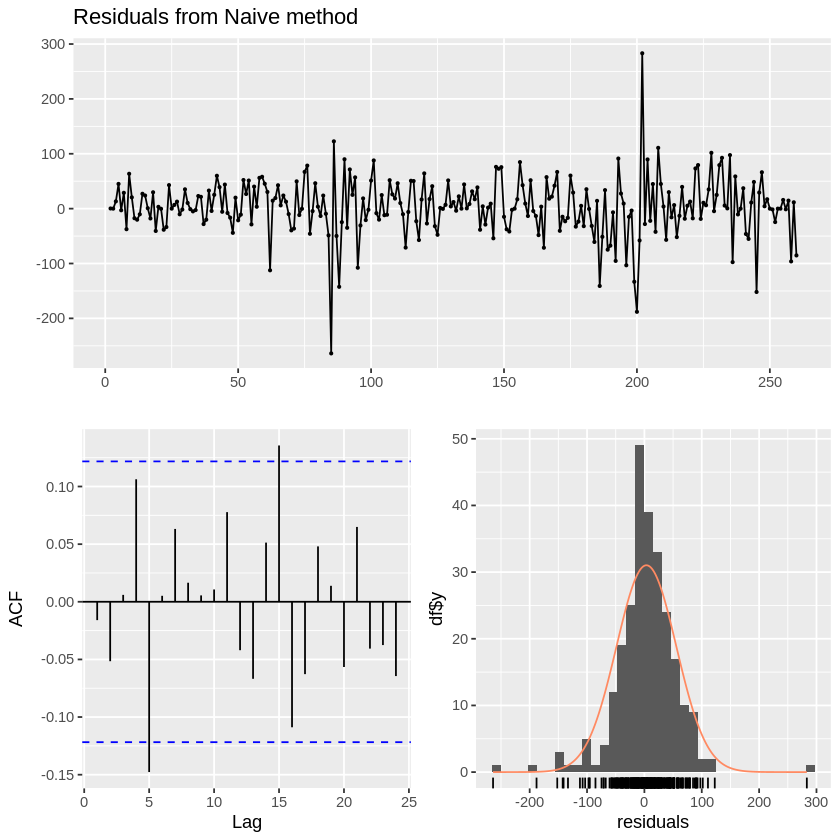

In [ ]:
psei |> naive() |> checkresiduals()

,Qtr1,Qtr2,Qtr3,Qtr4
1994,2288317,2090216,1876635,4282886
1995,2272045,2045286,,


,Qtr1,Qtr2,Qtr3,Qtr4
2007,,,3146959,6365355
2008,3748852,3371867,3467460,6227369


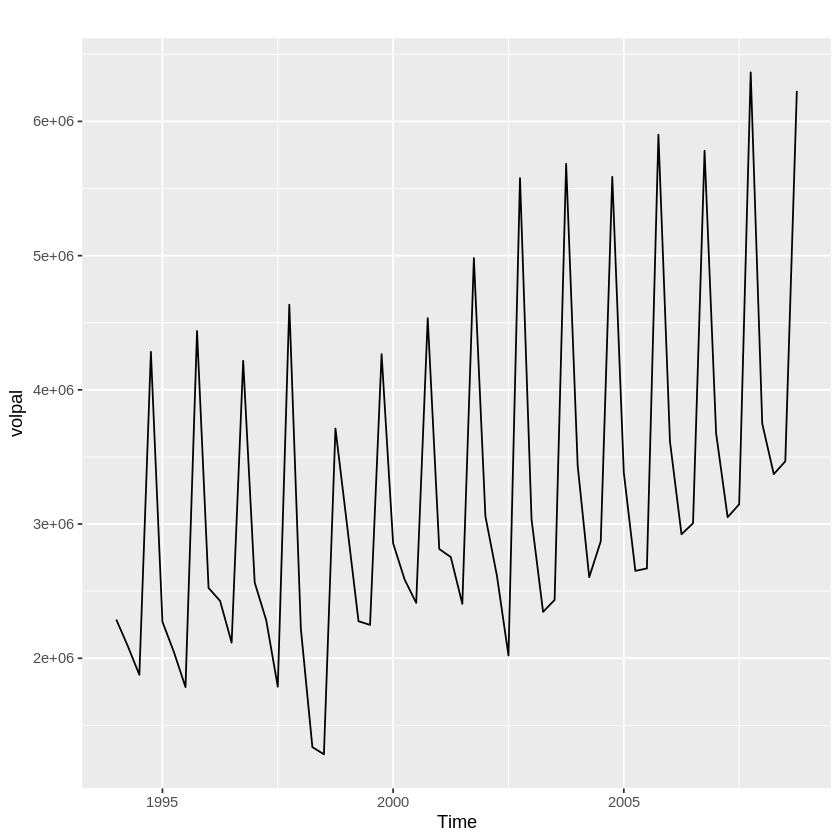

In [ ]:
## Using Window dataset

autoplot(volpal)
head(volpal)
tail(volpal)

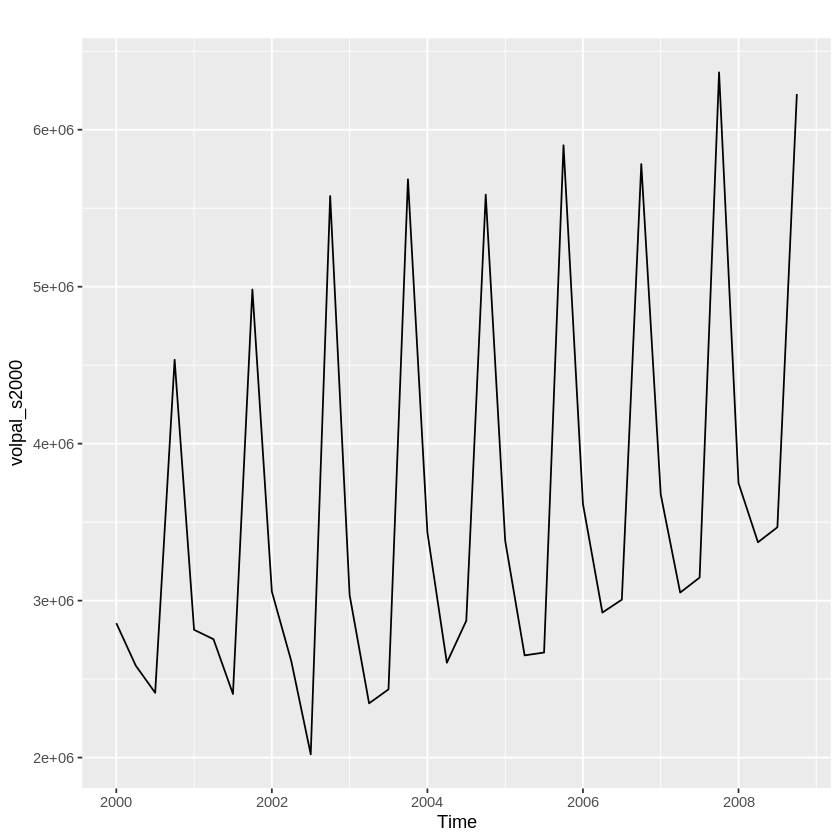

In [ ]:
volpal_s2000 <- window(volpal, start=c(2000,1))

autoplot(volpal_s2000)

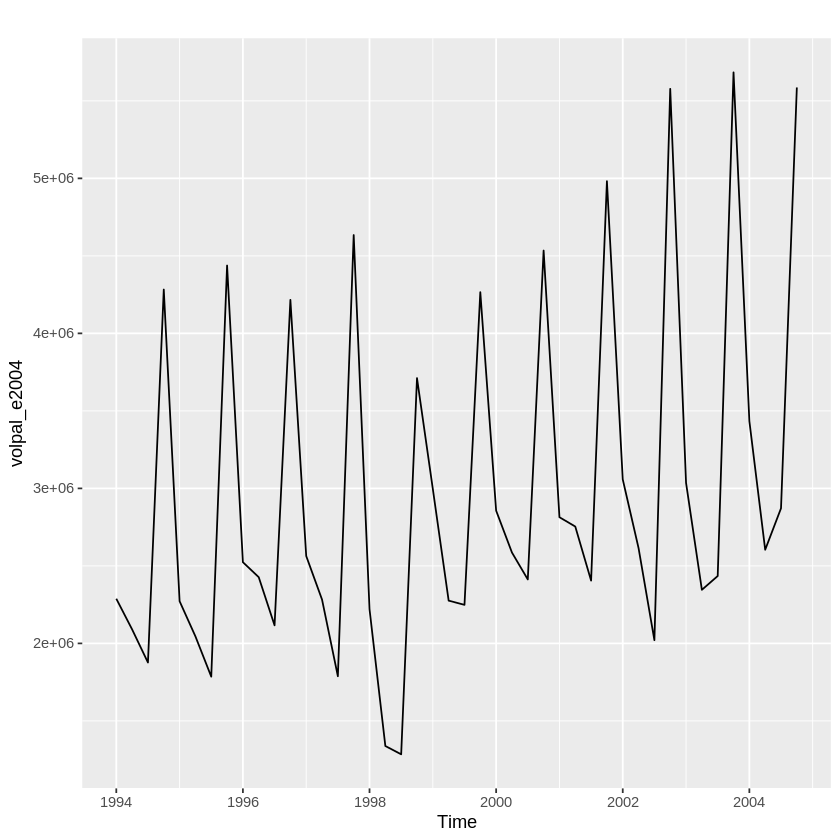

In [ ]:
volpal_e2004 <- window(volpal, end = c(2004,4))

autoplot(volpal_e2004)

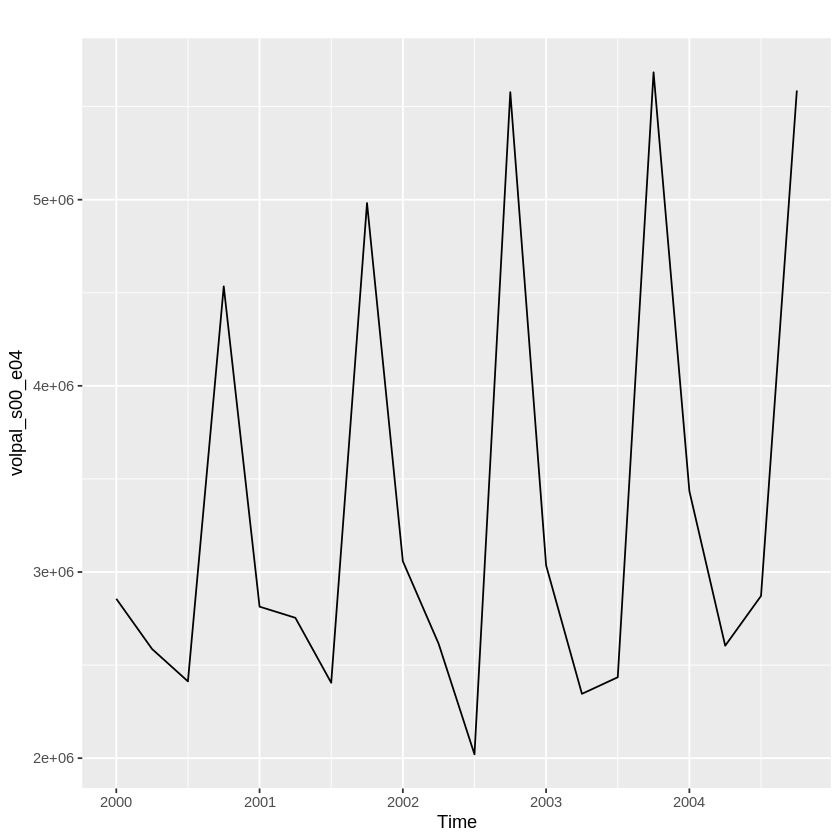

In [ ]:
volpal_s00_e04 <- window(volpal, start = c(2000,1), end = c(2004,4))

autoplot(volpal_s00_e04)

In [ ]:
length(volpal)

[1] 60

[1] 20

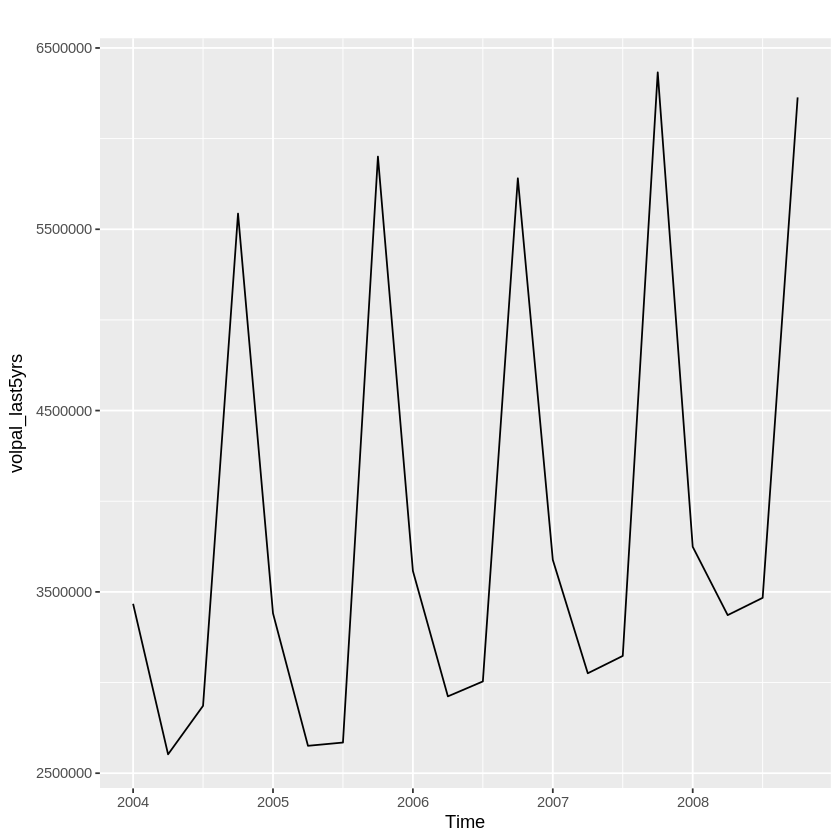

In [ ]:
## Subsetting

volpal_last5yrs <- subset(volpal, start = length(volpal) - 4*5 +1)

length(volpal_last5yrs)

autoplot(volpal_last5yrs)

[1] 30

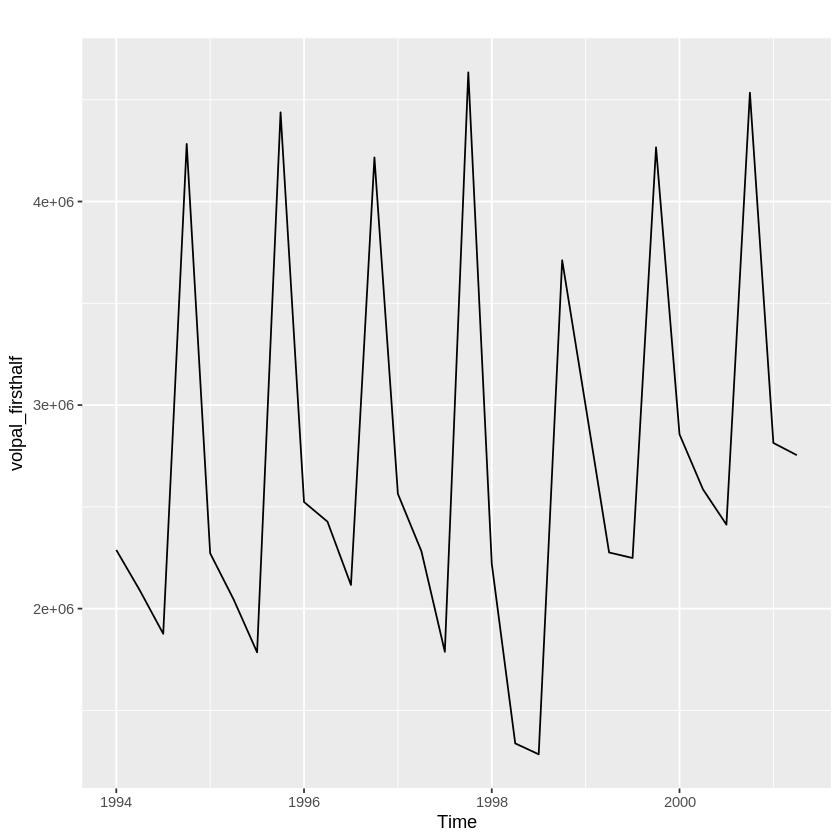

In [ ]:
volpal_firsthalf <- subset(volpal, end = length(volpal)/2)

length(volpal_firsthalf)

autoplot(volpal_firsthalf)

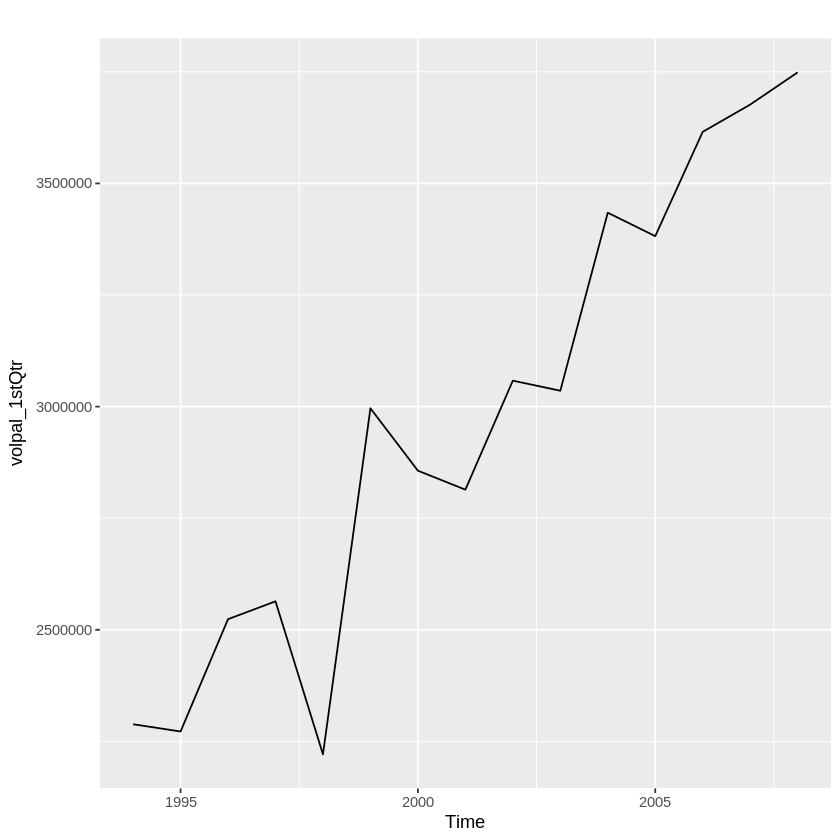

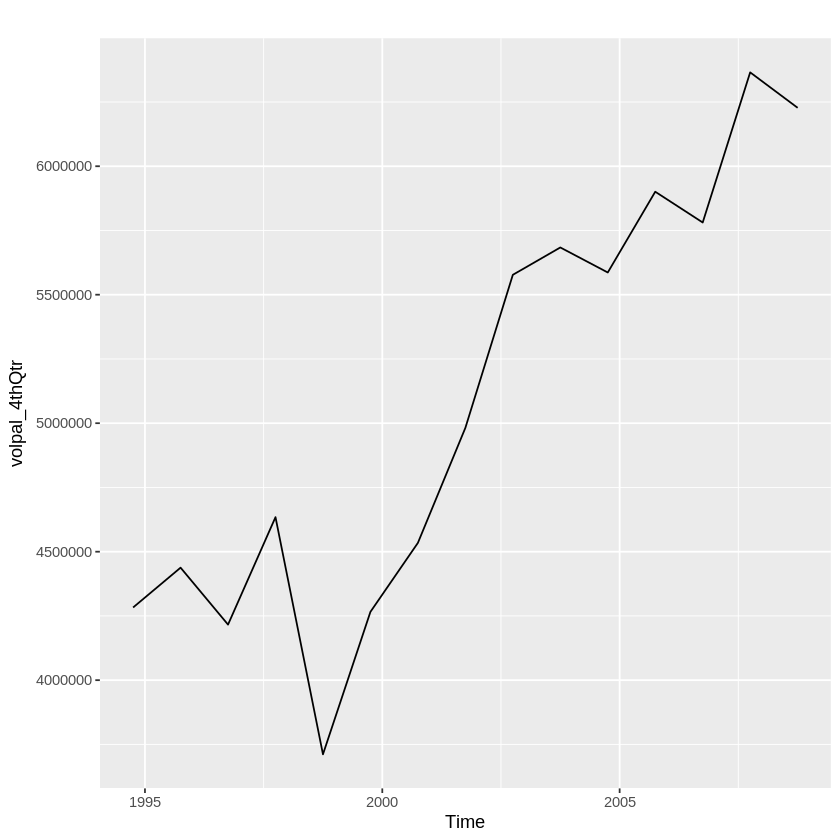

In [ ]:
## Specific Seasons in a Subset

volpal_1stQtr <- subset(volpal, season = 1)

volpal_4thQtr <- subset(volpal, season = 4)

autoplot(volpal_1stQtr)
autoplot(volpal_4thQtr)

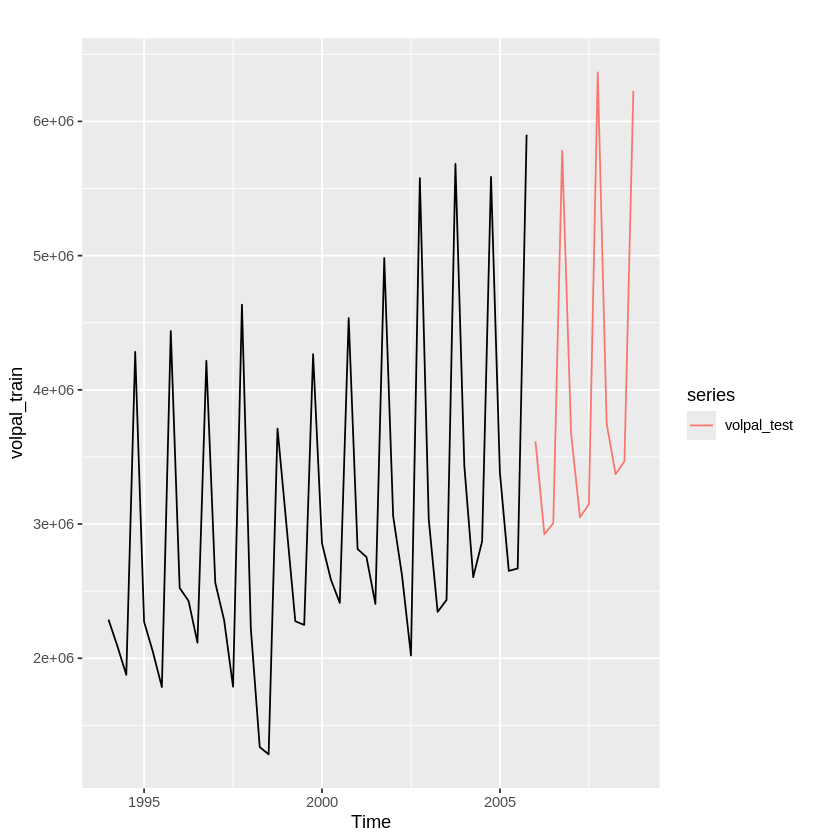

In [ ]:
## Head and Tail Functions

volpal_train <- head(volpal, 48)
volpal_test <- tail(volpal, 12)

autoplot(volpal_train) + autolayer(volpal_test)

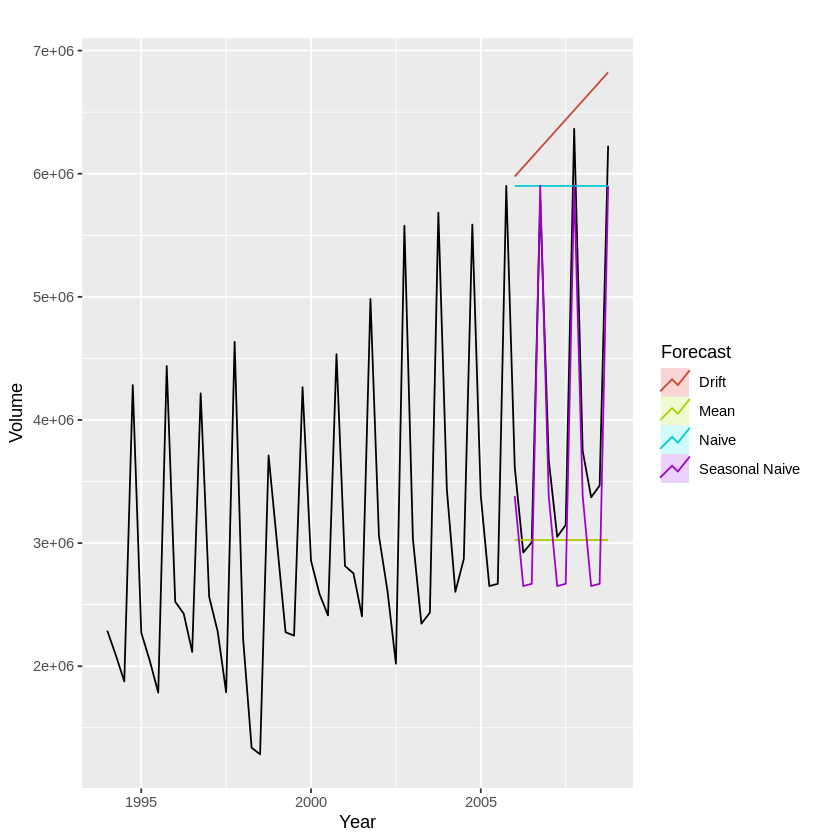

In [ ]:
## Error Metrics

volpalfit1 <- meanf(volpal_train, h = 12)
volpalfit2 <- naive(volpal_train, h = 12)
volpalfit3 <- snaive(volpal_train, h = 12)
volpalfit4 <- rwf(volpal_train, drift = TRUE, h = 12)

autoplot(volpal) +
  autolayer(volpalfit1, series = "Mean", PI = F) +
  autolayer(volpalfit2, series = "Naive", PI = F) +
  autolayer(volpalfit3, series = "Seasonal Naive", PI = F) +
  autolayer(volpalfit4, series = "Drift", PI = F) +
  xlab("Year") + ylab("Volume") +
  guides(colour = guide_legend(title = "Forecast"))

In [ ]:
accuracy(volpalfit1, volpal_test)
accuracy(volpalfit2, volpal_test)
accuracy(volpalfit3, volpal_test)
accuracy(volpalfit4, volpal_test)

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,1.552346e-10,1165327,930315.5,-13.85261,32.83047,2.944641,-0.09356769,NA
Test set,1.007135e+06,1598312,1027043.2,19.06035,19.73833,3.250804,-0.16267072,0.9936924


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,76862.26,1686936,1296492,-9.58536,38.36393,4.103667,-0.3812291,NA
Test set,-1868972.33,2243510,2000812,-57.90215,59.99230,6.332984,-0.1626707,1.221531


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,92385.25,409931.7,315935.1,1.30273,12.31340,1.000000,0.3150601,NA
Test set,381119.42,442155.9,401080.8,10.66432,11.00961,1.269504,0.3436796,0.2531232


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,2.475470e-11,1685184,1326799,-12.46859,40.13926,4.199592,-0.3812291,NA
Test set,-2.368577e+06,2646109,2368577,-70.66371,70.66371,7.497036,-0.2212809,1.440608


In [ ]:
e_vp <- tsCV(volpal, snaive, h = 1)
sqrt(mean(e_vp^2, na.rm = TRUE))
mean(abs(e_vp), na.rm = TRUE)

[1] 387569.8

[1] 302053.2

In [ ]:
accuracy(volpalfit3, volpal_test)[2,2:3]

RMSE      MAE 
442155.9 401080.8

In [ ]:
sqrt(mean(residuals(snaive(volpal))^2, na.rm=TRUE))
volpal |> snaive() |> residuals() |> abs() |> mean(na.rm = TRUE)

[1] 384099.9

[1] 296949.9

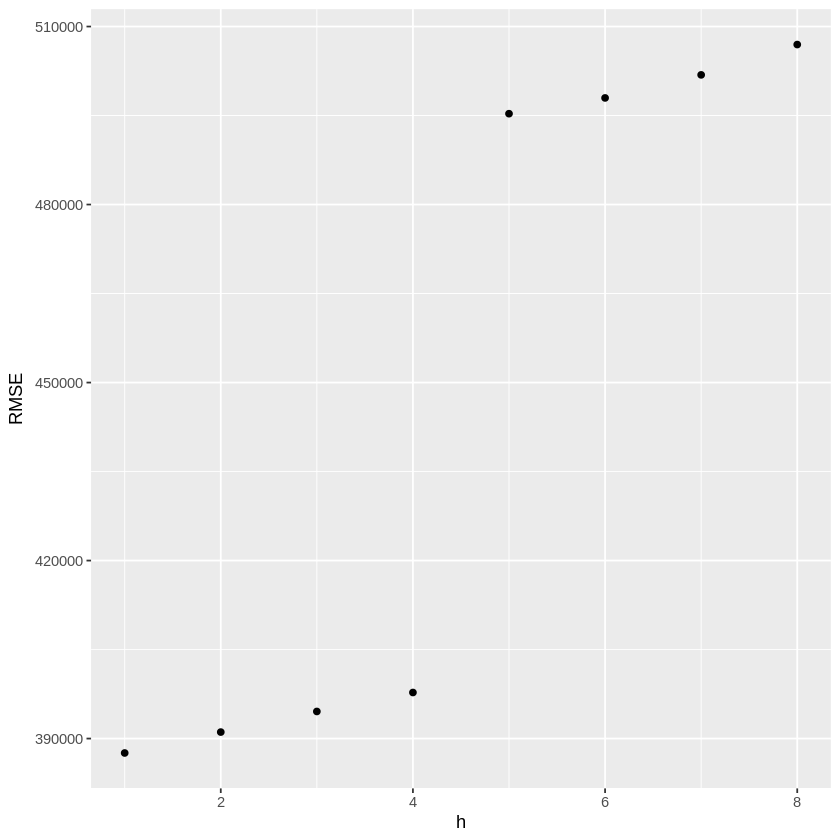

In [ ]:
## Multiple Horizon

e_vp_8 <- tsCV(volpal, snaive, h = 8)

rmse <- sqrt(colMeans(e_vp_8^2, na.rm = TRUE))

data.frame(h = 1:8, RMSE = rmse) |>
  ggplot(aes(x = h, y = RMSE)) + geom_point()

        Point Forecast   Lo 50   Hi 50   Lo 80   Hi 80   Lo 95   Hi 95
2009 Q1        3748852 3489781 4007923 3256608 4241096 2996030 4501674
2009 Q2        3371867 3112796 3630938 2879623 3864111 2619045 4124689
2009 Q3        3467460 3208389 3726531 2975216 3959704 2714638 4220282
2009 Q4        6227369 5968298 6486440 5735125 6719613 5474547 6980191
2010 Q1        3748852 3382470 4115234 3052714 4444990 2684201 4813503
2010 Q2        3371867 3005485 3738249 2675729 4068005 2307216 4436518
2010 Q3        3467460 3101078 3833842 2771322 4163598 2402809 4532111
2010 Q4        6227369 5860987 6593751 5531231 6923507 5162718 7292020

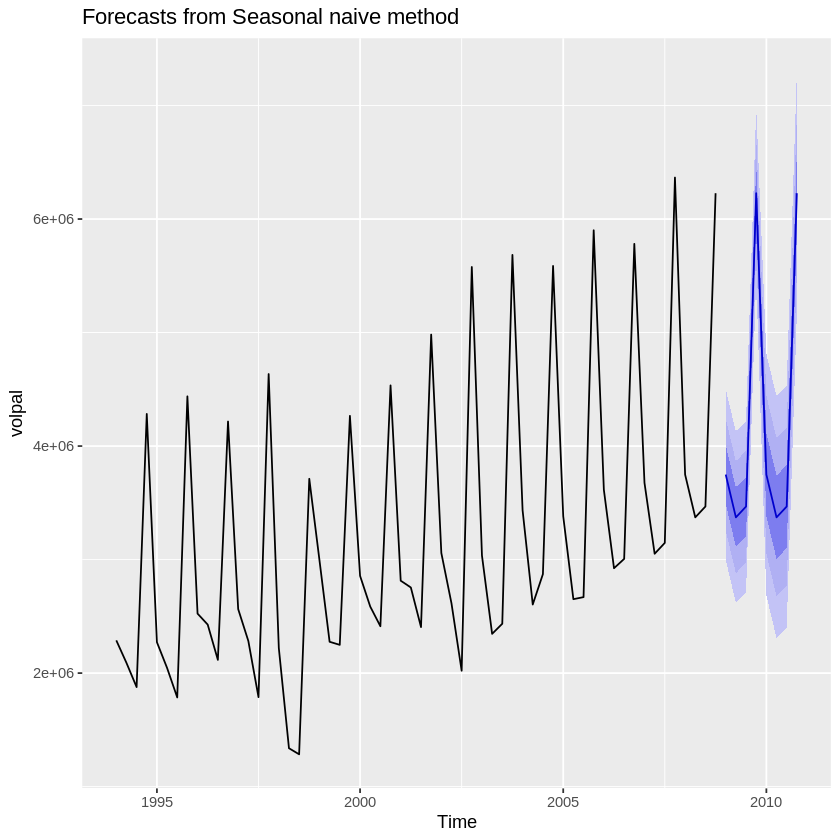

In [ ]:
# Prediction Intervals

snaive(volpal, level = c(50,80, 95))
autoplot(snaive(volpal, level = c(50,80, 95)))

        Point Forecast   Lo 50   Hi 50   Lo 80   Hi 80   Lo 95   Hi 95
2009 Q1        3748852 3489781 4007923 3256608 4241096 2996030 4501674
2009 Q2        3371867 3112796 3630938 2879623 3864111 2619045 4124689
2009 Q3        3467460 3208389 3726531 2975216 3959704 2714638 4220282
2009 Q4        6227369 5968298 6486440 5735125 6719613 5474547 6980191
2010 Q1        3748852 3382470 4115234 3052714 4444990 2684201 4813503
2010 Q2        3371867 3005485 3738249 2675729 4068005 2307216 4436518
2010 Q3        3467460 3101078 3833842 2771322 4163598 2402809 4532111
2010 Q4        6227369 5860987 6593751 5531231 6923507 5162718 7292020

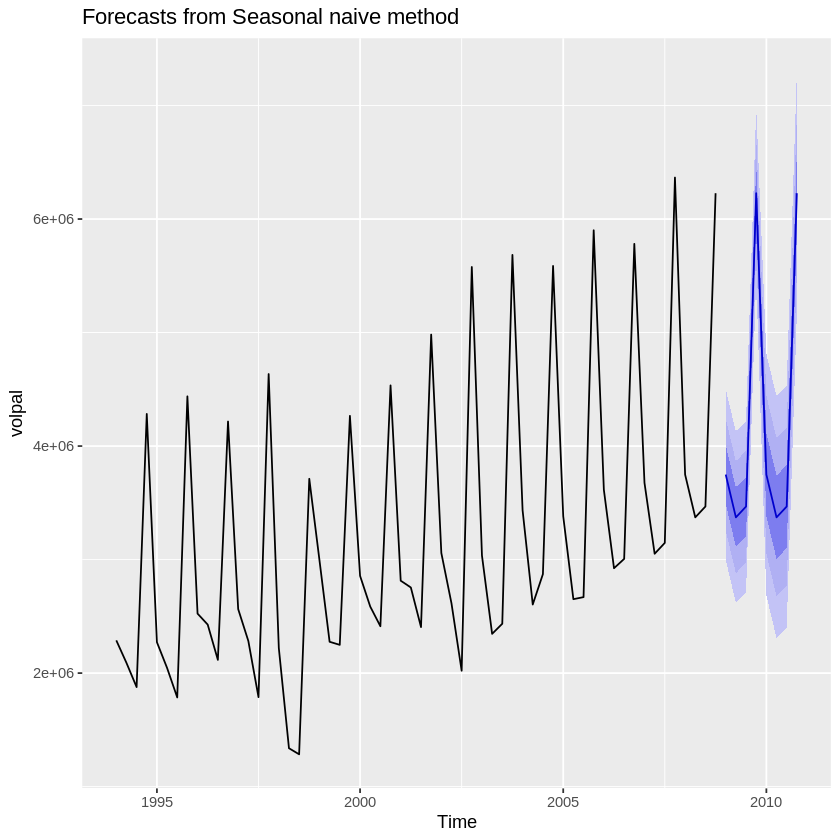

In [ ]:
# Bootstrapped Prediction Intervals

snaive(volpal, level = c(50,80, 95), bootstrap = TRUE)
autoplot(snaive(volpal, level = c(50,80, 95), bootstrap = TRUE))